### **Student ID:** 24B2289

### **Title of the Project:** Machine Learning Based Heart Disease Risk Prediction

### **Source of Data:** UCI Cleveland Heart Disease Dataset
https://archive.ics.uci.edu/ml/datasets/heart+Disease

### **Objective of this Work:**

To develop a machine learning model that can predict the risk of heart disease using patient health data such as age, blood pressure, cholesterol, chest pain type, and ECG results.

To generate a comparison of different machine learning models and find which model gives the most accurate and reliable prediction.

To set up a simple prediction system where patient values can be entered manually and the model can estimate heart disease risk with clear result analysis.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") # suppress warnings for cleaner notebook output

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import MinMaxScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.svm                import SVC
from sklearn.metrics            import (accuracy_score,
                                        confusion_matrix,
                                        classification_report,
                                        roc_auc_score)
import urllib.request
import os

print("All libraries imported successfully.")

All libraries imported successfully.


**Data Collection and Import**

The Cleveland Heart Disease dataset is collected from the UCI repository and loaded into a dataframe for analysis. Since the original target has multiple disease levels, it is converted into binary form (0 = No Disease, 1 = Disease Present) to make this a classification problem.

In [22]:
URL  = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
        "/heart-disease/processed.cleveland.data")
FILE = "heart.csv"

if not os.path.exists(FILE):
    urllib.request.urlretrieve(URL, FILE)

COLUMNS = ["age", "sex", "chest_pain", "resting_bp", "cholesterol",
           "fasting_sugar", "rest_ecg", "max_hr", "angina",
           "st_depression", "st_slope", "vessels", "thal", "target"]

df = pd.read_csv(FILE, header=None, names=COLUMNS, na_values="?")

df["target"] = (df["target"] > 0).astype(int)

print(f"Dataset loaded : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded : 303 rows, 14 columns

First 5 rows:


,age,sex,chest_pain,resting_bp,cholesterol,fasting_sugar,rest_ecg,max_hr,angina,st_depression,st_slope,vessels,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Exploratory Data Analysis (EDA)**

This section examines the basic structure of the dataset, including total patients, feature count, missing values, and disease distribution. This helps in understanding the data before preprocessing and model training.

In [23]:
print("=== EXPLORATORY DATA ANALYSIS (EDA) ===\n")
print(f"Total patients   : {len(df)}")
print(f"Total features   : {len(df.columns) - 1}")
print(f"Missing values   : {df.isnull().sum().sum()}")
print(f"\nDisease cases    : {df['target'].sum()}  "
      f"({df['target'].mean()*100:.1f}%)")
print(f"No disease cases : {(df['target']==0).sum()}  "
      f"({(df['target']==0).mean()*100:.1f}%)")
print("\n=== STATISTICAL SUMMARY ===\n")
df.describe().round(2)

=== EXPLORATORY DATA ANALYSIS (EDA) ===

Total patients   : 303
Total features   : 13
Missing values   : 6

Disease cases    : 139  (45.9%)
No disease cases : 164  (54.1%)

=== STATISTICAL SUMMARY ===



,age,sex,chest_pain,resting_bp,cholesterol,fasting_sugar,rest_ecg,max_hr,angina,st_depression,st_slope,vessels,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


**EDA Observations**

Key observations from the dataset:

1. The dataset contains 303 patient records with 13 clinical features.  
2. Missing values are very few and can be handled easily during preprocessing.  
3. Disease and non-disease classes are fairly balanced, making model evaluation more reliable.  
4. Statistical summary helps understand feature ranges such as age, cholesterol, blood pressure, and heart rate.

**Data Cleaning and Preprocessing**

Missing values are filled using median values, and categorical features are cast to integer type to ensure consistent data types for model training.

In [24]:
df["vessels"] = df["vessels"].fillna(df["vessels"].median())
df["thal"]    = df["thal"].fillna(df["thal"].median())

for col in ["sex","chest_pain","fasting_sugar",
            "rest_ecg","angina","st_slope",
            "vessels","thal","target"]:
    df[col] = df[col].astype(int)

print(f"Missing values after cleaning : {df.isnull().sum().sum()}")
print("Data cleaning complete.")

Missing values after cleaning : 0
Data cleaning complete.


**Data Visualization and Feature Analysis**

Several plots are generated to understand feature behaviour and their relation with heart disease.

Main goals:
- Visualize disease vs non-disease class distribution  
- Compare age and cholesterol trends between both classes  
- Study correlation among clinical features  
- Observe spread of important medical features using box plots

These visual insights help in understanding which features may contribute strongly to prediction.

PLOT 1 — Class distribution

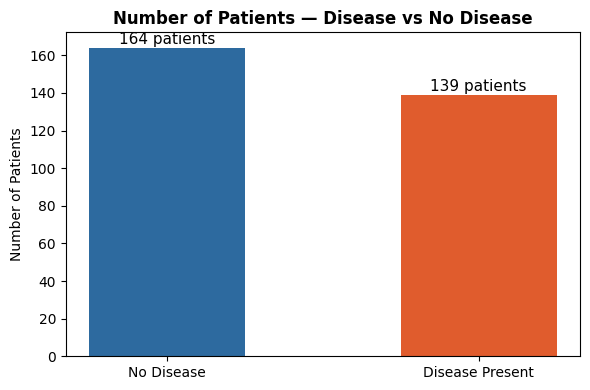

In [25]:
plt.figure(figsize=(6, 4))
counts = df["target"].value_counts().sort_index()
bars   = plt.bar(["No Disease", "Disease Present"],
                 counts.values,
                 color=["#2D6A9F", "#E05C2D"],
                 width=0.5)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f"{val} patients",
             ha="center", fontsize=11)

plt.title("Number of Patients — Disease vs No Disease",
          fontweight="bold")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("plot1_class_distribution.png")
plt.show()

The dataset shows a fairly balanced distribution between disease and non-disease cases, which makes model training and evaluation more reliable.

PLOT 2 — Age & cholesterol by disease status

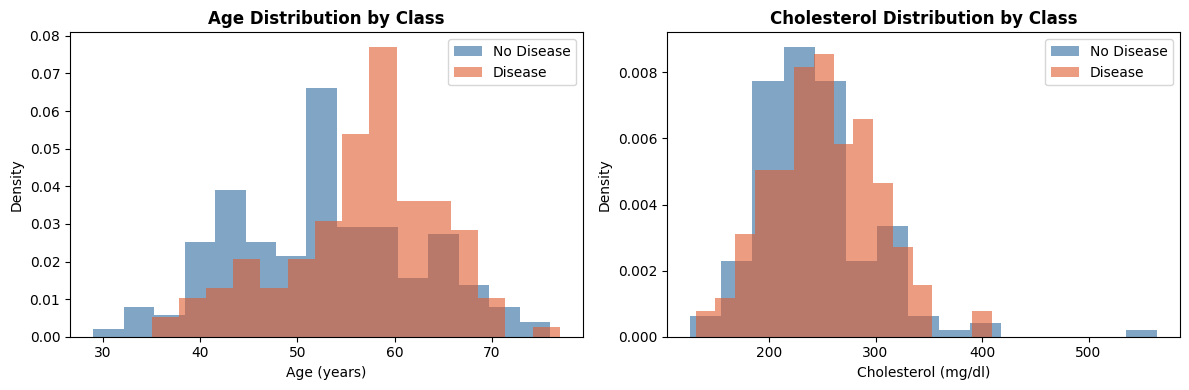

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, color, lbl in zip([0,1],
                            ["#2D6A9F","#E05C2D"],
                            ["No Disease","Disease"]):
    sub = df[df["target"]==cls]
    axes[0].hist(sub["age"], bins=15, alpha=0.6,
                 color=color, label=lbl, density=True)
    axes[1].hist(sub["cholesterol"], bins=15, alpha=0.6,
                 color=color, label=lbl, density=True)

axes[0].set_title("Age Distribution by Class",  fontweight="bold")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].set_title("Cholesterol Distribution by Class", fontweight="bold")
axes[1].set_xlabel("Cholesterol (mg/dl)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("plot2_age_cholesterol.png")
plt.show()

Patients with heart disease generally show different age and cholesterol distributions compared to healthy patients, indicating that these features may contribute to prediction.

PLOT 3 — Correlation heatmap

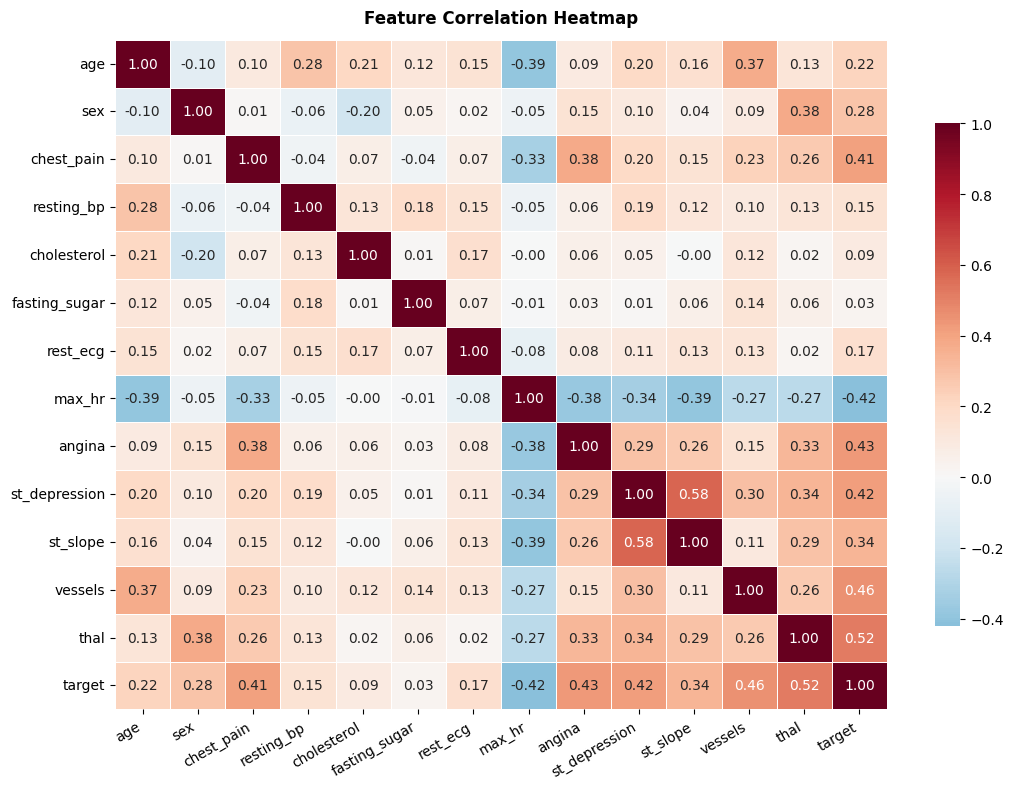

In [27]:
plt.figure(figsize=(11, 8))
corr = df.corr().round(2)

sns.heatmap(corr,
            annot=True, fmt=".2f",
            cmap="RdBu_r", center=0,
            linewidths=0.4,
            cbar_kws={"shrink": 0.75})

plt.title("Feature Correlation Heatmap", fontweight="bold", pad=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plot3_correlation_heatmap.png")
plt.show()

The correlation heatmap highlights relationships among clinical features and shows which variables are more strongly associated with heart disease risk.

PLOT 4 — Key clinical features box plots

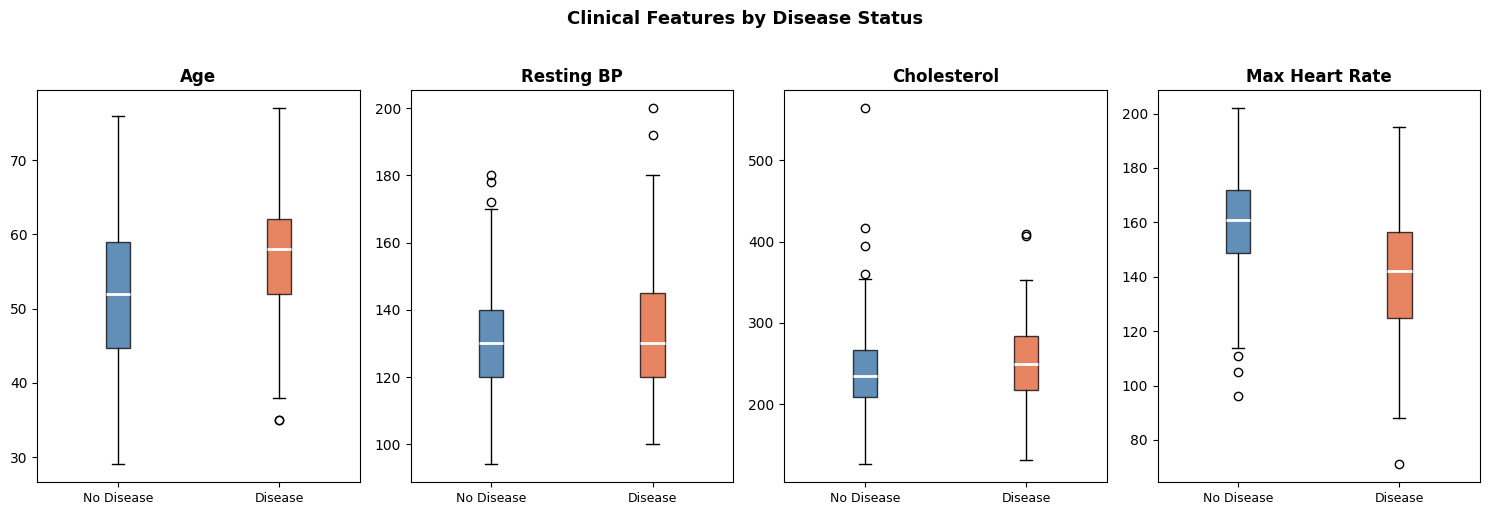

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
features  = ["age", "resting_bp", "cholesterol", "max_hr"]
labels    = ["Age", "Resting BP", "Cholesterol", "Max Heart Rate"]

for ax, feat, lbl in zip(axes, features, labels):
    data = [df.loc[df["target"]==0, feat],
            df.loc[df["target"]==1, feat]]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2))
    for patch, color in zip(bp["boxes"], ["#2D6A9F","#E05C2D"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks([1,2])
    ax.set_xticklabels(["No Disease","Disease"], fontsize=9)
    ax.set_title(lbl, fontweight="bold")

plt.suptitle("Clinical Features by Disease Status",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("plot4_boxplots.png")
plt.show()

The box plots show noticeable variation in clinical measurements between healthy and diseased patients, supporting their importance in model prediction.

**Feature Selection, Data Split, and Scaling**

Input features and target variable are separated for model training.

Processing steps:
- Dataset split into Training set (80%)
- Dataset split into Testing set (20%)
- Stratified sampling used to maintain class balance
- MinMaxScaler applied for feature normalization

Scaling helps models like Logistic Regression and SVM perform better because they are sensitive to feature magnitude.

In [29]:
FEATURES = [c for c in df.columns if c != "target"]

X = df[FEATURES].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Scale all features to [0, 1]
# IMPORTANT: fit only on training data to avoid data leakage
scaler       = MinMaxScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Scaling  done    : all features now in [0, 1]")

Training samples : 242
Testing  samples : 61
Scaling  done    : all features now in [0, 1]


### **Machine Learning Models Used and Comparison**

For the same prediction objective, four classification models are trained and compared:

1. **Logistic Regression** – used as a simple baseline model for comparison.  
2. **Decision Tree Classifier** – captures rule-based patterns in the data.  
3. **Random Forest Classifier** – improves prediction stability by combining multiple decision trees.  
4. **Support Vector Machine (SVM)** – included because it performs well on structured classification problems.

Each model is evaluated using:
- **Accuracy Score**
- **ROC-AUC Score**

**Why ROC-AUC is also used:**  
ROC-AUC measures how well the model separates disease and non-disease cases across different classification thresholds, giving a more reliable evaluation than Accuracy alone.

**Hyperparameter Choices:**  
The model hyperparameters were selected to balance prediction performance and generalization. Logistic Regression uses `C=1.0` and `max_iter=1000` to ensure proper convergence during training. Decision Tree uses `max_depth=5` to control model complexity on a relatively small dataset. Random Forest uses `n_estimators=300`, `max_depth=8`, `min_samples_split=5`, and `min_samples_leaf=2` to improve prediction stability while reducing overfitting. SVM uses an RBF kernel with probability estimation enabled, making it suitable for nonlinear classification and ROC-AUC evaluation.

This comparison helps in selecting the model that gives the most reliable heart disease prediction.

In [30]:
# Train all four models
models = {
    "Logistic Regression" : LogisticRegression(C=1.0,
                                               max_iter=1000,
                                               random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=5,
                                                   random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=300,
                                                   max_depth=8,
                                                   min_samples_split=5,
                                                   min_samples_leaf=2,
                                                   random_state=42),
    "SVM"                 : SVC(kernel="rbf",
                                C=1.0,
                                gamma="scale",
                                probability=True,
                                random_state=42),
}

results = {}   # stores accuracy, predictions, probabilities

for name, model in models.items():
    model.fit(X_train_sc, y_train)

    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)

    results[name] = {"model"   : model,
                     "y_pred"  : y_pred,
                     "y_prob"  : y_prob,
                     "accuracy": acc,
                     "auc"     : auc}

    print(f"{name:<24}  Accuracy = {acc:.4f}   ROC-AUC = {auc:.4f}")

Logistic Regression       Accuracy = 0.8525   ROC-AUC = 0.9426
Decision Tree             Accuracy = 0.7869   ROC-AUC = 0.8047


Random Forest             Accuracy = 0.9016   ROC-AUC = 0.9535
SVM                       Accuracy = 0.7869   ROC-AUC = 0.9188


PLOT 5 — Model Accuracy and ROC-AUC comparison

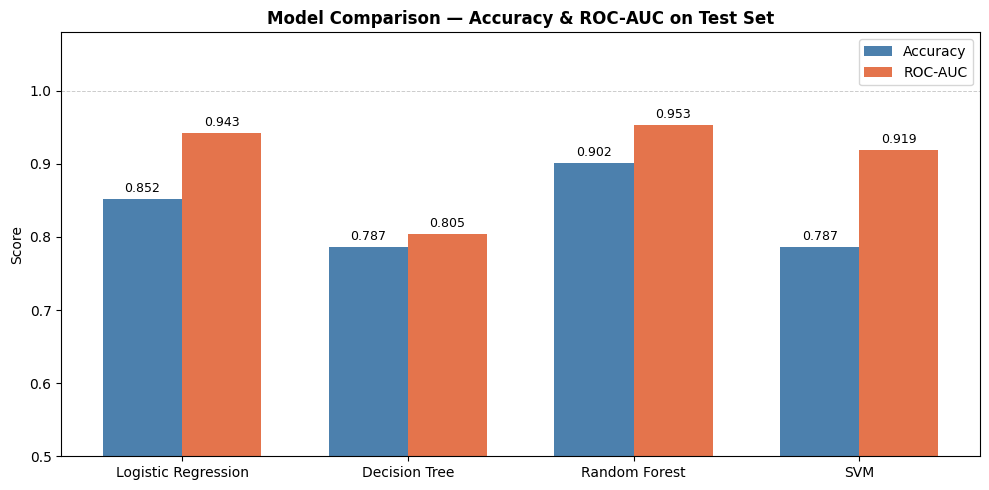

In [31]:
names = list(results.keys())
accs  = [results[n]["accuracy"] for n in names]
aucs  = [results[n]["auc"]      for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, accs, width=w, color="#2D6A9F",
            alpha=0.85, label="Accuracy")
b2 = ax.bar(x + w/2, aucs, width=w, color="#E05C2D",
            alpha=0.85, label="ROC-AUC")

for bar, val in [(b, v) for bars, vals in [(b1,accs),(b2,aucs)]
                          for b,v in zip(bars,vals)]:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center",
            va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0.5, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Accuracy & ROC-AUC on Test Set",
             fontweight="bold")
ax.legend(fontsize=10)
ax.axhline(1.0, color="#ccc", linewidth=0.7, linestyle="--")

plt.tight_layout()
plt.savefig("plot5_model_comparison.png")
plt.show()

**Model Performance Analysis**

Key findings:

1. All four models performed reasonably well on the test set.  
2. Random Forest achieved the strongest combined Accuracy and ROC-AUC performance.  
3. Ensemble learning helped improve prediction stability compared to a single Decision Tree.  
4. Random Forest is selected as the final model for prediction.

**Model Performance Evaluation**

The trained models are evaluated using confusion matrices, classification report, ROC curves, and feature importance analysis to better understand prediction performance.

PLOT 6 — Confusion matrices

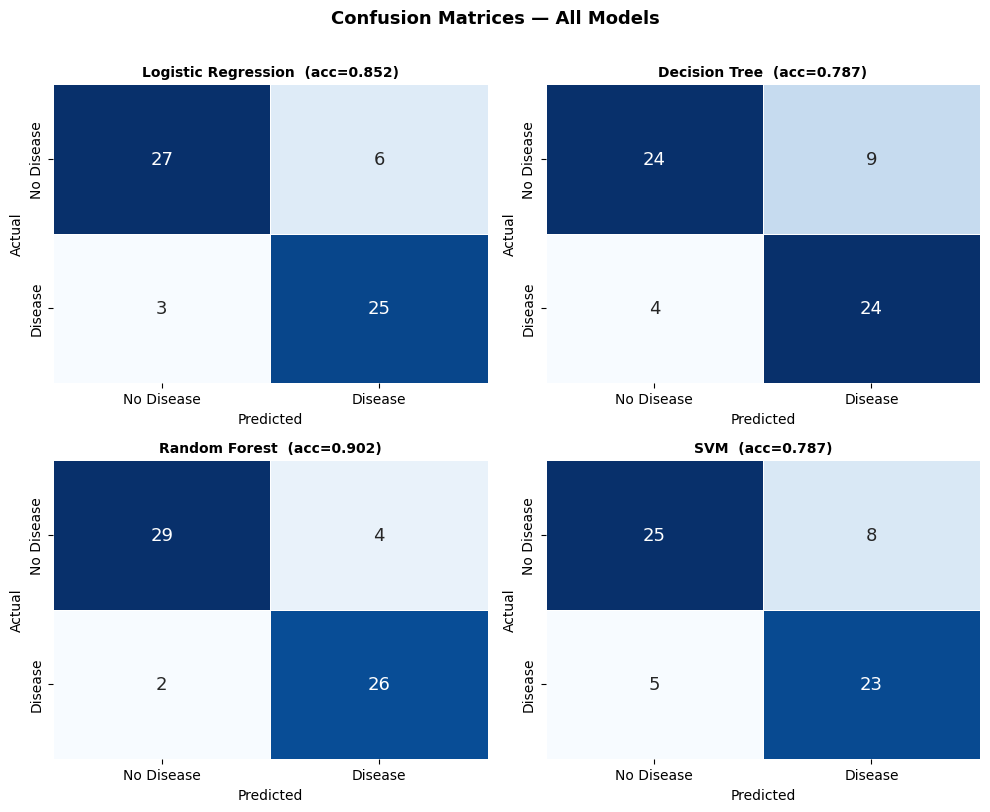

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, name in zip(axes, names):
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(cm, ax=ax,
                annot=True, fmt="d",
                cmap="Blues", linewidths=0.5,
                xticklabels=["No Disease","Disease"],
                yticklabels=["No Disease","Disease"],
                cbar=False, annot_kws={"size":13})
    acc = results[name]["accuracy"]
    ax.set_title(f"{name}  (acc={acc:.3f})",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plot6_confusion_matrices.png")
plt.show()

PLOT 7 — ROC curves

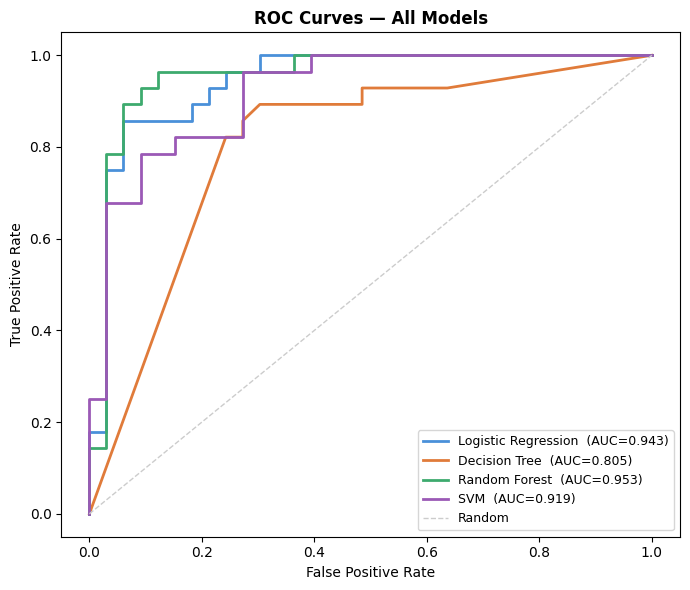

In [33]:
from sklearn.metrics import roc_curve

COLORS = {"Logistic Regression":"#4A90D9",
          "Decision Tree"      :"#E07B3A",
          "Random Forest"      :"#3DAA6E",
          "SVM"                :"#9B59B6"}

plt.figure(figsize=(7, 6))
for name in names:
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    auc          = results[name]["auc"]
    plt.plot(fpr, tpr, color=COLORS[name], linewidth=2,
             label=f"{name}  (AUC={auc:.3f})")

plt.plot([0,1],[0,1], color="#ccc",
         linewidth=1, linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("plot7_roc_curves.png")
plt.show()

PLOT 8 — Random Forest feature importance

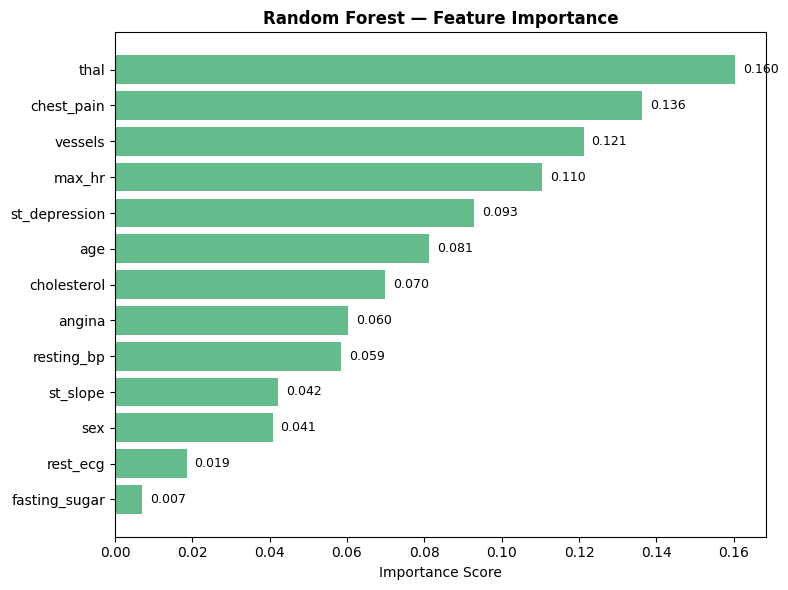

In [34]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_,
                        index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
bars = plt.barh(importances.index, importances.values,
                color="#3DAA6E", alpha=0.80)

for bar, val in zip(bars, importances.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)

plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importance",
          fontweight="bold")
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()

### **Patient Risk Prediction**
The best-performing model is selected with highest ROC-AUC on the test set
and used for predicting heart disease risk for manually entered patient clinical parameters.

In [35]:
best_name  = max(results, key=lambda n: results[n]["auc"])
best_model = results[best_name]["model"]

print("  MODEL SELECTION SUMMARY")
print("=" * 48)
for name in names:
    marker = "  ← BEST" if name == best_name else ""
    print(f"  {name:<24}"
          f"  AUC={results[name]['auc']:.4f}"
          f"  Acc={results[name]['accuracy']:.4f}"
          f"{marker}")

print(f"\n  Best model : {best_name}")

  MODEL SELECTION SUMMARY
  Logistic Regression       AUC=0.9426  Acc=0.8525
  Decision Tree             AUC=0.8047  Acc=0.7869
  Random Forest             AUC=0.9535  Acc=0.9016  ← BEST
  SVM                       AUC=0.9188  Acc=0.7869

  Best model : Random Forest


**Full classification report**

In [36]:
print(f"Classification Report — {best_name}\n")
print(classification_report(
    y_test,
    results[best_name]["y_pred"],
    target_names=["No Disease", "Disease"]
))

Classification Report — Random Forest

              precision    recall  f1-score   support

  No Disease       0.94      0.88      0.91        33
     Disease       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



**Cross-validation of Best Model**

To check model stability, 5-fold cross-validation is performed on the best model. This helps confirm that model performance remains consistent across different data splits.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipe = Pipeline([('scaler', MinMaxScaler()), ('clf', best_model)])
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc')

print("5-Fold Cross-validation ROC-AUC Scores :", cv_scores.round(3))
print("Mean ROC-AUC :", cv_scores.mean().round(3))

5-Fold Cross-validation ROC-AUC Scores : [0.883 0.957 0.893 0.907 0.887]
Mean ROC-AUC : 0.905


The cross-validation scores remain consistently high across different folds, indicating that the selected model is stable and generalizes well beyond a single train-test split.

**Prediction vs Ground Truth**

This section compares actual results with model predictions.

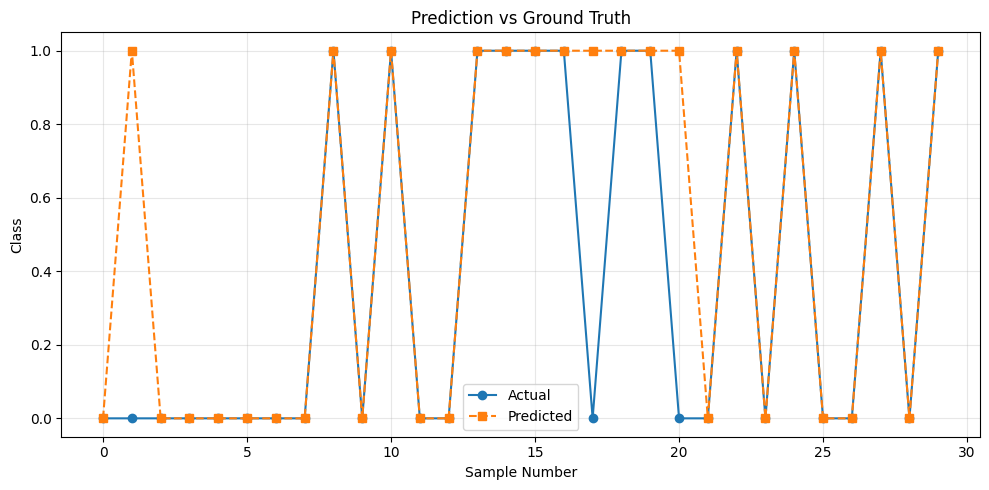

In [38]:
plt.figure(figsize=(10,5))
plt.plot(y_test[:30], 'o-', label='Actual')
plt.plot(results[best_name]["y_pred"][:30], 's--', label='Predicted')
plt.title("Prediction vs Ground Truth")
plt.xlabel("Sample Number")
plt.ylabel("Class")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Prediction vs Ground Truth Analysis**

The prediction vs ground truth comparison shows that the selected Random Forest model correctly classifies most patient cases, with only a few mismatches between predicted and actual labels. This indicates that the model has learned meaningful clinical patterns from the dataset and provides reliable classification performance on unseen test samples.

**Prediction Demo**

**Feature Guide**

```text
age           : patient age in years
sex           : 1 = male,  0 = female
chest_pain    : 1 = typical angina,  2 = atypical,  3 = non-anginal,  4 = asymptomatic
resting_bp    : resting blood pressure in mm Hg
cholesterol   : serum cholesterol in mg/dl
fasting_sugar : 1 if fasting blood sugar > 120 mg/dl,  else 0
rest_ecg      : 0 = normal,  1 = ST-T abnormality,  2 = LV hypertrophy
max_hr        : maximum heart rate achieved during exercise
angina        : 1 = exercise-induced angina,  0 = no
st_depression : ST depression induced by exercise (e.g. 1.4)
st_slope      : 1 = upsloping,  2 = flat,  3 = downsloping
vessels       : number of major vessels coloured (0, 1, 2 or 3)
thal          : 3 = normal,  6 = fixed defect,  7 = reversible defect
```

In [39]:
patient = {
    "age"          : 54,
    "sex"          : 1,
    "chest_pain"   : 3,
    "resting_bp"   : 140,
    "cholesterol"  : 260,
    "fasting_sugar": 0,
    "rest_ecg"     : 1,
    "max_hr"       : 138,
    "angina"       : 0,
    "st_depression": 1.4,
    "st_slope"     : 2,
    "vessels"      : 1,
    "thal"         : 3,
}

# ── Run prediction ────────────────────────────────────────────
raw_vec    = np.array([[patient[f] for f in FEATURES]])

# scaler was fit on training data only — same scaling is applied here for consistent prediction
scaled_vec = scaler.transform(raw_vec)

probability = best_model.predict_proba(scaled_vec)[0, 1]
prediction  = best_model.predict(scaled_vec)[0]

risk_label  = ("HIGH RISK"     if probability >= 0.60 else
               "MODERATE RISK" if probability >= 0.35 else
               "LOW RISK")

# ── Print result ──────────────────────────────────────────────
print("=" * 48)
print("  HEART DISEASE RISK PREDICTION")
print("=" * 48)
print()
print(f"  Model used         : {best_name}")
print()
print("  Patient values entered:")
for feat, val in patient.items():
    print(f"    {feat:<16} : {val}")
print()
print(f"  Prediction         : {'Disease Present' if prediction==1 else 'No Disease'}")
print(f"  Probability        : {probability*100:.1f}%")
print(f"  Risk Level         : {risk_label}")
print()
print("=" * 48)

# ── Visual result bar ─────────────────────────────────────────
bar_filled = int(probability * 30)
bar_empty  = 30 - bar_filled
bar_color  = ("HIGH    " if probability >= 0.60 else
              "MODERATE" if probability >= 0.35 else
              "LOW     ")

print(f"\n  Risk bar : [{'█' * bar_filled}{'░' * bar_empty}]"
      f"  {probability*100:.1f}%  →  {bar_color}")
print()

  HEART DISEASE RISK PREDICTION

  Model used         : Random Forest

  Patient values entered:
    age              : 54
    sex              : 1
    chest_pain       : 3
    resting_bp       : 140
    cholesterol      : 260
    fasting_sugar    : 0
    rest_ecg         : 1
    max_hr           : 138
    angina           : 0
    st_depression    : 1.4
    st_slope         : 2
    vessels          : 1
    thal             : 3

  Prediction         : No Disease
  Probability        : 43.9%
  Risk Level         : MODERATE RISK


  Risk bar : [█████████████░░░░░░░░░░░░░░░░░]  43.9%  →  MODERATE



**Testing on Different Patient Cases**

Prediction on sample patient cases manually selected from the original dataset to observe model behaviour on different health conditions.

In [40]:
#sample cases selected manually from the original dataset
test_patients = [
    # ( age, sex, cp,  rbp, chol, fs, ecg, hr,  ang, std, sls, ves, thal )
    (  34,   0,   2,  118,  210,  0,   0,  192,   0,  0.7,  1,   0,   3 ),  # young female
    (  67,   1,   4,  160,  286,  0,   2,  108,   1,  1.5,  2,   3,   3 ),  # older male
    (  54,   1,   3,  150,  232,  0,   2,  165,   0,  1.6,  1,   0,   7 ),  # middle-aged male
]

print(f"{'No.':<4} {'Age':<5} {'Sex':<6} {'Probability':>12}"
      f"  {'Prediction':<18} {'Risk'}")
print("-" * 62)

for i, vals in enumerate(test_patients, 1):
    raw    = np.array([vals])

    # apply the same training scaler for consistent preprocessing
    scaled = scaler.transform(raw)

    prob   = best_model.predict_proba(scaled)[0, 1]
    pred   = best_model.predict(scaled)[0]
    risk   = ("HIGH"     if prob >= 0.60 else
              "MODERATE" if prob >= 0.35 else
              "LOW")
    sex_lbl = "Male" if vals[1]==1 else "Female"
    outcome = "Disease Present" if pred==1 else "No Disease"
    print(f"{i:<4} {vals[0]:<5} {sex_lbl:<6} {prob*100:>11.1f}%"
          f"  {outcome:<18} {risk}")

No.  Age   Sex     Probability  Prediction         Risk
--------------------------------------------------------------
1    34    Female         1.9%  No Disease         LOW
2    67    Male          92.0%  Disease Present    HIGH
3    54    Male          35.3%  No Disease         MODERATE


### **Project Summary**


Title   : ML Based Heart Disease Risk Prediction

Dataset : UCI Cleveland Heart Disease

Samples : 303 patients, 13 clinical features

Steps completed:
```text
  1. Data loading and preprocessing        (6 missing values handled)
  2. Exploratory data analysis             (8 plots generated with analysis)
  3. Feature scaling                       (MinMaxScaler normalization)
  4. Train / test split                    (80% / 20% with stratified sampling)
  5. Four models trained                   (LR, DT, RF, SVM)
  6. Model evaluation                      (Accuracy, ROC-AUC, confusion matrix)
  7. Best model selection                  (based on ROC-AUC score)
  8. Feature importance analysis           (important predictors identified)
  9. Cross-validation                      (5-fold model stability check)
 10. Prediction testing                    (manual patient case evaluation)
```

Model results on test set:

```text
  Logistic Regression   Acc = 0.853   AUC = 0.943
  Decision Tree         Acc = 0.787   AUC = 0.805
  Random Forest         Acc = 0.902   AUC = 0.954   ← Best
  SVM                   Acc = 0.787   AUC = 0.919
```
Final outcome:

Random Forest provided the most reliable overall performance for heart disease risk prediction.

### **Conclusion**

Among the four models tested, **Random Forest** achieved the best predictive performance based on both Accuracy Score and ROC-AUC Score. Feature importance analysis showed that thal, chest pain type, vessel count, maximum heart rate, and ST depression had strong influence on prediction in this dataset.

Overall, this project demonstrates that machine learning can be effectively used for clinical heart disease risk prediction, with Random Forest providing the most reliable performance among the models tested.